# Face Detection using Haar Cascade

## 🎯 Objective

Learn how to detect faces using OpenCV's Haar Cascade classifier.

This notebook demonstrates two approaches:

1. Face Detection using a local image.
2. Face Detection by downloading the classifier and image from the internet (Google Colab).

---

## Concepts Covered

- Haar Cascade
- CascadeClassifier
- Grayscale Conversion
- detectMultiScale()
- Bounding Boxes

## Method 1

### Face Detection using Haar Cascade

### 🎯 Objective

Detect human faces in an image using OpenCV's pre-trained Haar Cascade classifier.

---

### 📚 Theory

Face Detection is one of the most common Computer Vision tasks.

OpenCV provides pre-trained Haar Cascade XML files that can detect faces without training a deep learning model.

#### Steps

1. Download Haar Cascade classifier.
2. Load an image.
3. Convert it to grayscale.
4. Detect faces.
5. Draw bounding boxes.
6. Display the output.

---

### 📦 Libraries Used

- OpenCV (`cv2`)
- urllib
- google.colab.patches

---

### 📖 Expected Output

The detected face will be highlighted with a green rectangle.

---

### 🔑 Key Concepts

- Haar Cascade
- CascadeClassifier
- detectMultiScale()
- Bounding Box
- Grayscale Image

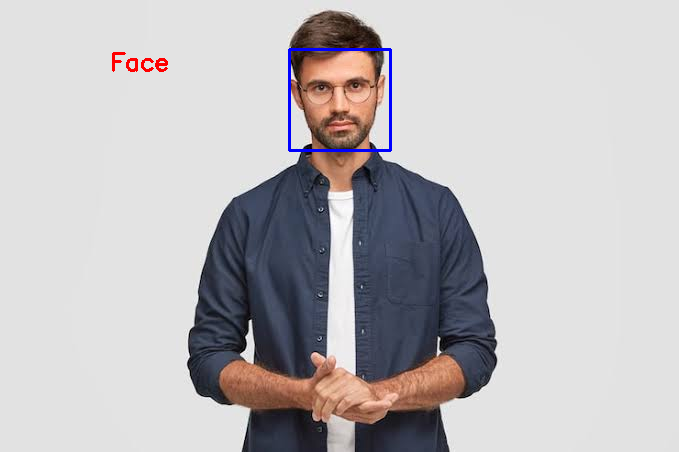

In [2]:
import cv2
from google.colab.patches import cv2_imshow


face_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)


if face_detector.empty():
    print("Failed to load Haar Cascade.")
    exit()


image = cv2.imread("/content/images.jpg")

if image is None:
    print("face.jpeg not found.")
    exit()


gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)


faces = face_detector.detectMultiScale(
    gray,
    scaleFactor=1.3,
    minNeighbors=5
)


for (x, y, w, h) in faces:
    cv2.rectangle(
        image,
        (x, y),
        (x + w, y + h),
        (255, 0, 0),
        2
    )

    cv2.putText(
    image,
    "Face",
    (110, 70),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.8,
    (0, 0, 255),
    2
)



cv2_imshow(image)

## Method 2

Instead of using a local image, download both the Haar Cascade XML file and the sample image directly from the internet.

This approach is useful when sharing notebooks on GitHub because anyone can run the notebook without uploading files.

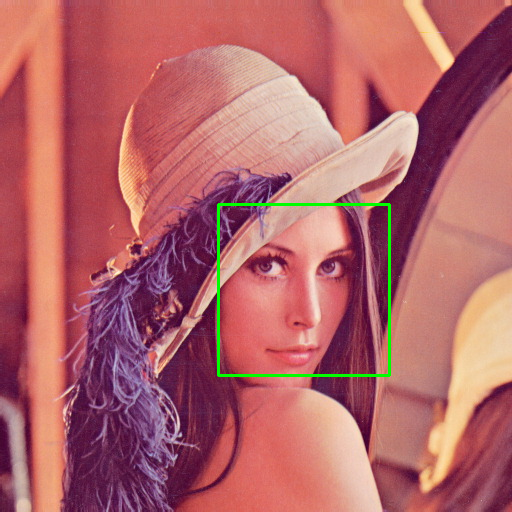

In [3]:
import cv2
import urllib.request
from google.colab.patches import cv2_imshow

cascade_url = "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml"
urllib.request.urlretrieve(cascade_url, "haarcascade_frontalface_default.xml")

face_detector = cv2.CascadeClassifier("haarcascade_frontalface_default.xml")

image_url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"
urllib.request.urlretrieve(image_url, "face.jpg")

image = cv2.imread("face.jpg")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

faces = face_detector.detectMultiScale(gray, 1.3, 5)

for (x, y, w, h) in faces:
    cv2.rectangle(image, (x, y), (x+w, y+h), (0, 255, 0), 2)

cv2_imshow(image)